# Experiment 08: Tuned 4-crop DenseNet121 Fine-tuning Strategy Comparison

This notebook follows the same research structure used in the previous experiments.

**Goal:** compare two training strategies on the selected tuned 4-crop model:

1. `full_finetuning`  
2. `freeze_unfreeze`

The base model is:

```text
4-crop DenseNet121
+ Class-weighted HybridChenOrdinalLoss
+ light augmentation
+ IMG_SIZE = 320
+ LR = 5e-5
+ ORDINAL_ALPHA = 0.20
```

This experiment should be run after Experiment 07A, where class-weighted HybridChenOrdinalLoss was selected as the best imbalance-handling method under the tuned 4-crop setting.

## 1. Imports & Environment Setup

In [22]:
from pathlib import Path
import os
import random
import json
import time
import math
from contextlib import nullcontext

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms, models, datasets

from sklearn.metrics import (
   accuracy_score,
   f1_score,
   confusion_matrix,
   classification_report,
   cohen_kappa_score,
   ConfusionMatrixDisplay
)

from tqdm import tqdm

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 2. Configuration Section

This section records all key experimental settings to make the experiment reproducible.

In [23]:
CONFIG = {
    "EXPERIMENT_NAME": "experiment08_tuned_4crop_finetuning_strategy",
    "IMG_SIZE": 320,
    "BATCH_SIZE": 16,
    "EPOCHS": 30,
    "LR": 5e-5,
    "WEIGHT_DECAY": 0.0,
    "SEED": 42,
    "MODEL_NAME": "4-crop DenseNet121",
    "LOSS": "ClassWeightedHybridChenOrdinalLoss",
    "NUM_CLASSES": 5,
    "NUM_CROPS": 4,
    "CROP_NAMES": ["wide", "center", "left_edge", "right_edge"],
    "DROPOUT": 0.3,
    "ORDINAL_ALPHA": 0.20,
    "PENALTY_DISTANCE": 2,
    "SQUARE_LOSS": False,
    "NORMALIZE_MATRIX": True,
    "USE_AMP": True,
    "NUM_WORKERS": 0,
    "PATIENCE": 7,
    "FREEZE_EPOCHS": 5,
    "SELECTION_METRIC": "val_qwk",
    "DATA_ROOT": "/kaggle/input/datasets/joylyuyue/split-data",
}

# 4-crop relative crop boxes
CROP_CONFIG = {
    "CENTER_CROP_WIDTH_RATIO": 0.70,
    "CENTER_CROP_HEIGHT_RATIO": 0.80,
    "EDGE_CROP_WIDTH_RATIO": 0.55,
    "EDGE_CROP_HEIGHT_RATIO": 0.80,
    "LEFT_CENTER_X_RATIO": 0.30,
    "RIGHT_CENTER_X_RATIO": 0.70,
    "CENTER_X_RATIO": 0.50,
    "CENTER_Y_RATIO": 0.50,
}

# Strategies compared in this experiment
FINETUNING_EXPERIMENTS = [
    {
        "name": "full_finetuning",
        "freeze_backbone_first": False,
        "freeze_epochs": 0,
        "description": "Train DenseNet121 backbone and classifier from epoch 1.",
    },
    {
        "name": "freeze_unfreeze",
        "freeze_backbone_first": True,
        "freeze_epochs": CONFIG["FREEZE_EPOCHS"],
        "description": "Freeze DenseNet121 backbone first, then unfreeze for full fine-tuning.",
    },
]

print(json.dumps(CONFIG, indent=2))
print(json.dumps(CROP_CONFIG, indent=2))
print(pd.DataFrame(FINETUNING_EXPERIMENTS))

{
  "EXPERIMENT_NAME": "experiment08_tuned_4crop_finetuning_strategy",
  "IMG_SIZE": 320,
  "BATCH_SIZE": 16,
  "EPOCHS": 30,
  "LR": 5e-05,
  "WEIGHT_DECAY": 0.0,
  "SEED": 42,
  "MODEL_NAME": "4-crop DenseNet121",
  "LOSS": "ClassWeightedHybridChenOrdinalLoss",
  "NUM_CLASSES": 5,
  "NUM_CROPS": 4,
  "CROP_NAMES": [
    "wide",
    "center",
    "left_edge",
    "right_edge"
  ],
  "DROPOUT": 0.3,
  "ORDINAL_ALPHA": 0.2,
  "PENALTY_DISTANCE": 2,
  "SQUARE_LOSS": false,
  "NORMALIZE_MATRIX": true,
  "USE_AMP": true,
  "NUM_WORKERS": 0,
  "PATIENCE": 7,
  "FREEZE_EPOCHS": 5,
  "SELECTION_METRIC": "val_qwk",
  "DATA_ROOT": "/kaggle/input/datasets/joylyuyue/split-data"
}
{
  "CENTER_CROP_WIDTH_RATIO": 0.7,
  "CENTER_CROP_HEIGHT_RATIO": 0.8,
  "EDGE_CROP_WIDTH_RATIO": 0.55,
  "EDGE_CROP_HEIGHT_RATIO": 0.8,
  "LEFT_CENTER_X_RATIO": 0.3,
  "RIGHT_CENTER_X_RATIO": 0.7,
  "CENTER_X_RATIO": 0.5,
  "CENTER_Y_RATIO": 0.5
}
              name  freeze_backbone_first  freeze_epochs  \
0  full_finet

## 3. Dataset Paths

The dataset should have the following Kaggle structure:

```text
/kaggle/input/datasets/joylyuyue/split-data/train
/kaggle/input/datasets/joylyuyue/split-data/val
/kaggle/input/datasets/joylyuyue/split-data/test
```

In [24]:
DATA_ROOT = Path(CONFIG["DATA_ROOT"])

TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR = DATA_ROOT / "val"
TEST_DIR = DATA_ROOT / "test"

OUTPUT_DIR = Path("/kaggle/working") / CONFIG["EXPERIMENT_NAME"]
RESULTS_DIR = OUTPUT_DIR / "results"
MODELS_DIR = OUTPUT_DIR / "models"
FIGURES_DIR = OUTPUT_DIR / "figures"

for p in [OUTPUT_DIR, RESULTS_DIR, MODELS_DIR, FIGURES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("DATA_ROOT:", DATA_ROOT)
print("TRAIN_DIR:", TRAIN_DIR)
print("VAL_DIR:", VAL_DIR)
print("TEST_DIR:", TEST_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

for d in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    if not d.exists():
        raise FileNotFoundError(f"Missing folder: {d}")

print("Dataset paths are valid.")

DATA_ROOT: /kaggle/input/datasets/joylyuyue/split-data
TRAIN_DIR: /kaggle/input/datasets/joylyuyue/split-data/train
VAL_DIR: /kaggle/input/datasets/joylyuyue/split-data/val
TEST_DIR: /kaggle/input/datasets/joylyuyue/split-data/test
OUTPUT_DIR: /kaggle/working/experiment08_tuned_4crop_finetuning_strategy
Dataset paths are valid.


## 4. Seed Fixing

In [25]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Keep benchmark True for speed on fixed-size inputs.
    torch.backends.cudnn.benchmark = True

set_seed(CONFIG["SEED"])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 5. Data Preprocessing

This experiment uses the selected tuned preprocessing:

- image size: 320
- light augmentation for training only
- no random augmentation for validation/test
- four anatomical crops:
  - `wide`: whole knee structure
  - `center`: central joint space
  - `left_edge`: left joint edge
  - `right_edge`: right joint edge

In [26]:
MEAN = [0.485, 0.485, 0.485]
STD = [0.229, 0.229, 0.229]

def make_crop_box(width, height, center_x_ratio, center_y_ratio, width_ratio, height_ratio):
    crop_w = int(width * width_ratio)
    crop_h = int(height * height_ratio)

    cx = int(width * center_x_ratio)
    cy = int(height * center_y_ratio)

    left = max(0, cx - crop_w // 2)
    upper = max(0, cy - crop_h // 2)
    right = min(width, left + crop_w)
    lower = min(height, upper + crop_h)

    # Adjust if clipping changed box size
    left = max(0, right - crop_w)
    upper = max(0, lower - crop_h)

    return (left, upper, right, lower)


class MultiCropTransform:
    def __init__(self, img_size=320, train=False):
        self.img_size = img_size
        self.train = train

        if train:
            self.pre_crop_aug = transforms.Compose([
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomAffine(
                    degrees=5,
                    translate=(0.02, 0.02),
                    scale=(0.97, 1.03),
                    fill=0
                ),
            ])
        else:
            self.pre_crop_aug = None

        self.post_crop_transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=MEAN, std=STD),
        ])

    def __call__(self, img):
        img = img.convert("RGB")

        if self.pre_crop_aug is not None:
            img = self.pre_crop_aug(img)

        w, h = img.size

        crops = []

        # 1. wide crop: full image
        crops.append(img)

        # 2. center crop: central joint space
        center_box = make_crop_box(
            w, h,
            CROP_CONFIG["CENTER_X_RATIO"],
            CROP_CONFIG["CENTER_Y_RATIO"],
            CROP_CONFIG["CENTER_CROP_WIDTH_RATIO"],
            CROP_CONFIG["CENTER_CROP_HEIGHT_RATIO"]
        )
        crops.append(img.crop(center_box))

        # 3. left edge crop
        left_box = make_crop_box(
            w, h,
            CROP_CONFIG["LEFT_CENTER_X_RATIO"],
            CROP_CONFIG["CENTER_Y_RATIO"],
            CROP_CONFIG["EDGE_CROP_WIDTH_RATIO"],
            CROP_CONFIG["EDGE_CROP_HEIGHT_RATIO"]
        )
        crops.append(img.crop(left_box))

        # 4. right edge crop
        right_box = make_crop_box(
            w, h,
            CROP_CONFIG["RIGHT_CENTER_X_RATIO"],
            CROP_CONFIG["CENTER_Y_RATIO"],
            CROP_CONFIG["EDGE_CROP_WIDTH_RATIO"],
            CROP_CONFIG["EDGE_CROP_HEIGHT_RATIO"]
        )
        crops.append(img.crop(right_box))

        crop_tensors = [self.post_crop_transform(crop) for crop in crops]
        return torch.stack(crop_tensors, dim=0)


train_transform = MultiCropTransform(img_size=CONFIG["IMG_SIZE"], train=True)
valid_transform = MultiCropTransform(img_size=CONFIG["IMG_SIZE"], train=False)

print("Train transform: 4-crop + light augmentation")
print("Validation/Test transform: 4-crop deterministic preprocessing")

Train transform: 4-crop + light augmentation
Validation/Test transform: 4-crop deterministic preprocessing


## 6. Dataset & Dataloader

This section prints the train/validation/test sizes and class distribution.

In [27]:
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=valid_transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=valid_transform)

class_names = train_dataset.classes
class_to_idx = train_dataset.class_to_idx

print("Number of classes:", len(class_names))
print("Class mapping:", class_to_idx)
print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))

def get_targets(dataset):
    if hasattr(dataset, "targets"):
        return np.array(dataset.targets)
    return np.array([label for _, label in dataset.samples])

def count_classes(dataset, split_name):
    targets = get_targets(dataset)
    rows = []
    for idx, name in enumerate(dataset.classes):
        rows.append({
            "split": split_name,
            "class_idx": idx,
            "class_name": name,
            "count": int((targets == idx).sum())
        })
    return pd.DataFrame(rows)

dist_df = pd.concat([
    count_classes(train_dataset, "train"),
    count_classes(val_dataset, "val"),
    count_classes(test_dataset, "test"),
], ignore_index=True)

display(dist_df)

train_targets = get_targets(train_dataset)
class_counts = np.bincount(train_targets, minlength=CONFIG["NUM_CLASSES"])

class_weights_np = class_counts.sum() / (CONFIG["NUM_CLASSES"] * class_counts)
class_weights = torch.tensor(class_weights_np, dtype=torch.float32).to(device)

class_weight_df = pd.DataFrame({
    "class_idx": list(range(CONFIG["NUM_CLASSES"])),
    "class_name": class_names,
    "train_count": class_counts,
    "class_weight": class_weights_np
})
display(class_weight_df)

print("Class weights:", class_weights.detach().cpu().numpy())

Number of classes: 5
Class mapping: {'0Normal': 0, '1Doubtful': 1, '2Mild': 2, '3Moderate': 3, '4Severe': 4}
Train size: 1024
Val size: 146
Test size: 294


,split,class_idx,class_name,count
0,train,0,0Normal,316
1,train,1,1Doubtful,308
2,train,2,2Mild,134
3,train,3,3Moderate,122
4,train,4,4Severe,144
5,val,0,0Normal,45
6,val,1,1Doubtful,44
7,val,2,2Mild,19
8,val,3,3Moderate,18
9,val,4,4Severe,20


,class_idx,class_name,train_count,class_weight
0,0,0Normal,316,0.648101
1,1,1Doubtful,308,0.664935
2,2,2Mild,134,1.528358
3,3,3Moderate,122,1.678689
4,4,4Severe,144,1.422222


Class weights: [0.6481013  0.66493505 1.5283582  1.6786885  1.4222223 ]


In [28]:
def create_loaders(batch_size):
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=CONFIG["NUM_WORKERS"],
        pin_memory=torch.cuda.is_available(),
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=CONFIG["NUM_WORKERS"],
        pin_memory=torch.cuda.is_available(),
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=CONFIG["NUM_WORKERS"],
        pin_memory=torch.cuda.is_available(),
    )

    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = create_loaders(CONFIG["BATCH_SIZE"])

batch_crops, batch_labels = next(iter(train_loader))
print("Batch crops shape:", batch_crops.shape)
print("Batch labels shape:", batch_labels.shape)
print("Expected shape: [B, 4, 3, IMG_SIZE, IMG_SIZE]")

Batch crops shape: torch.Size([16, 4, 3, 320, 320])
Batch labels shape: torch.Size([16])
Expected shape: [B, 4, 3, IMG_SIZE, IMG_SIZE]


## 7. Visualization

This section displays:

1. original image
2. transformed 4-crop sample
3. CLAHE preview
4. augmented 4-crop examples

CLAHE is shown only as a visual reference and is **not** used in training for this experiment.

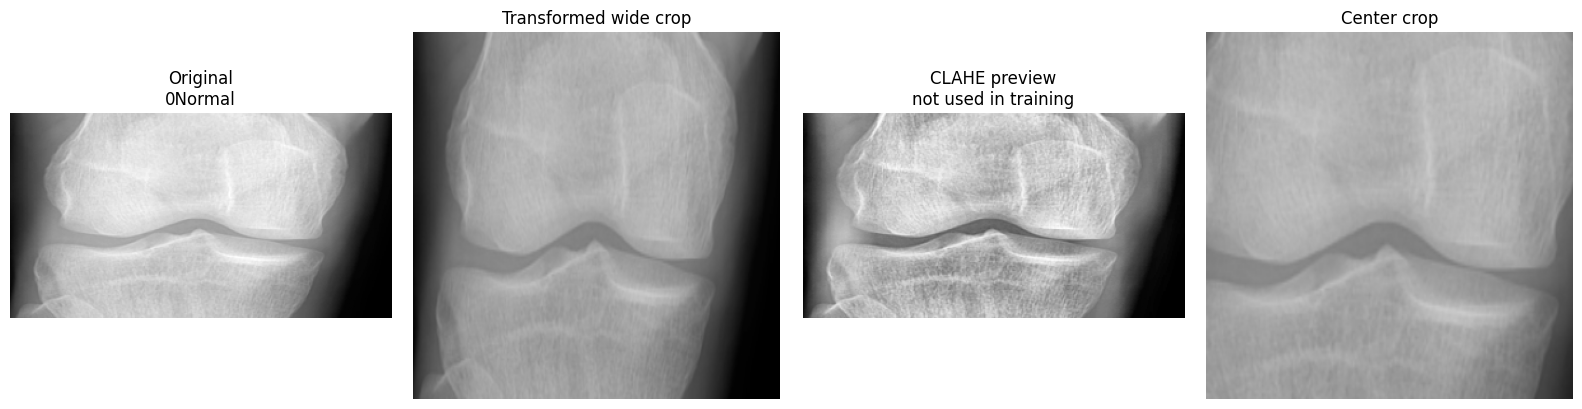

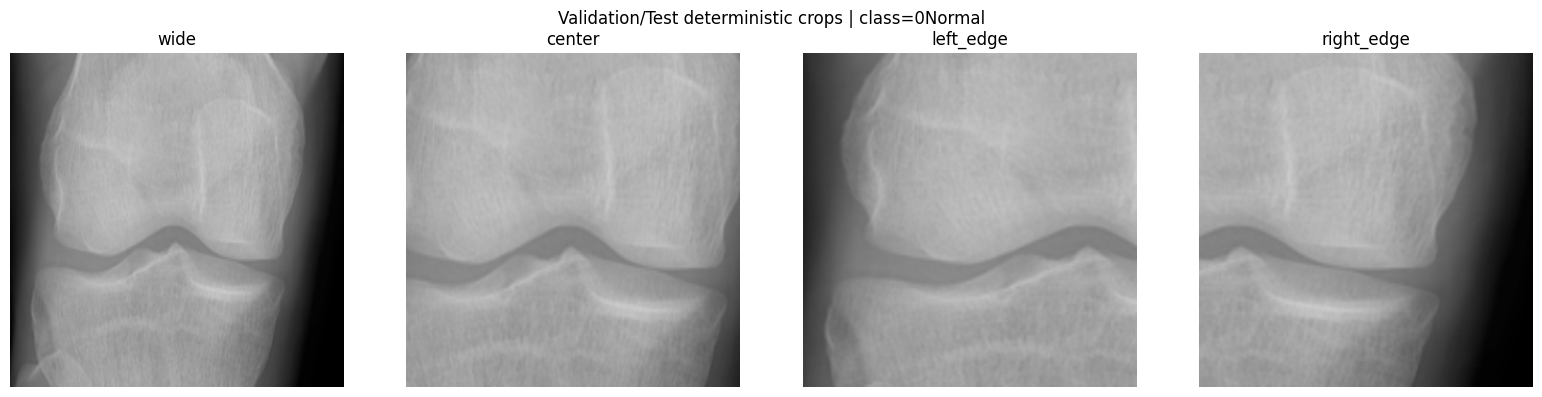

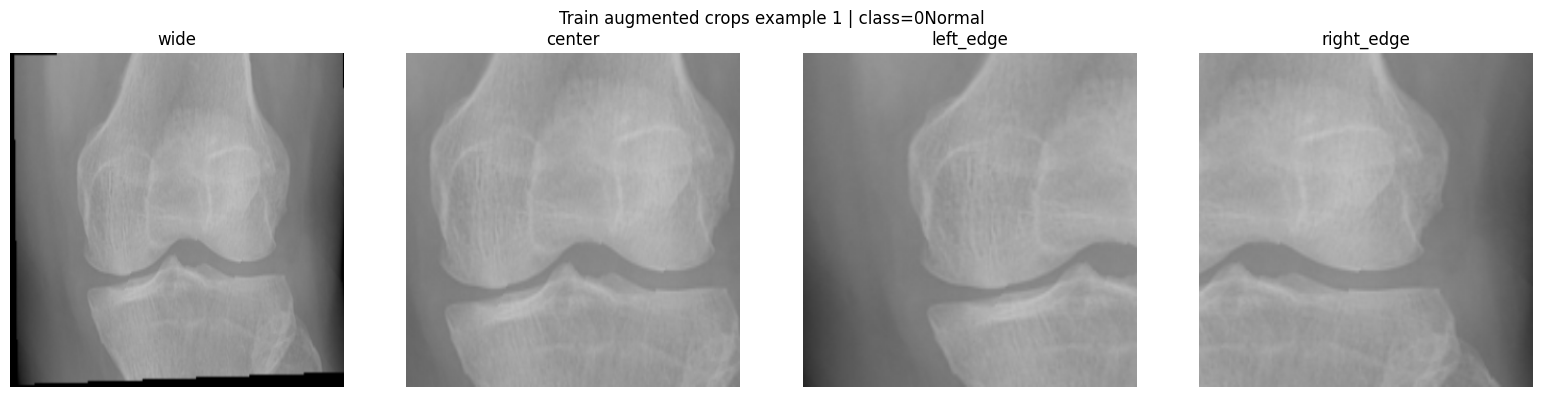

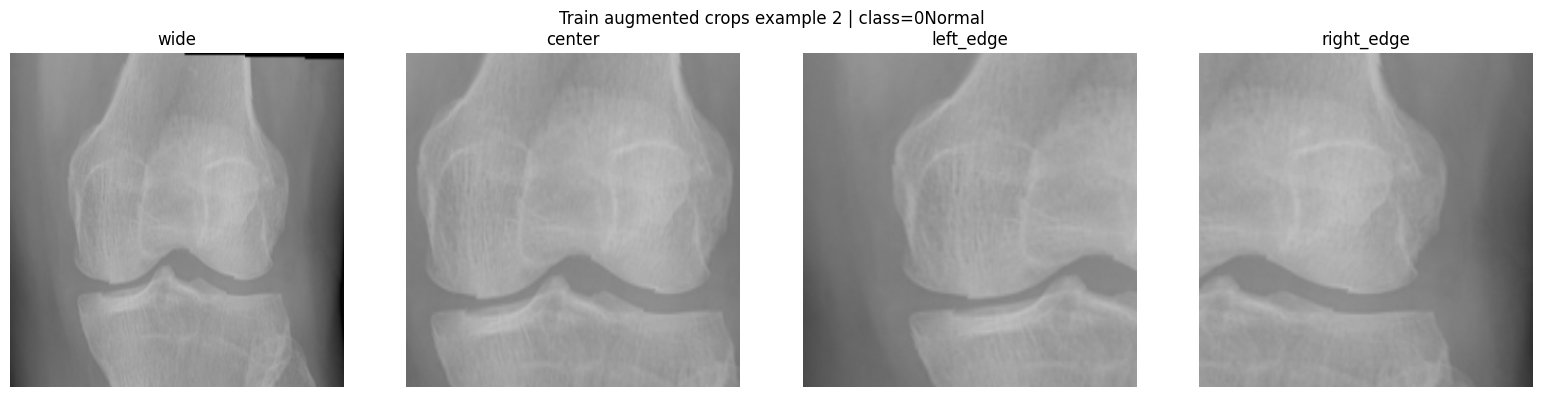

In [29]:
def denormalize_tensor(img_tensor, mean=MEAN, std=STD):
    img = img_tensor.detach().cpu().clone()
    mean_t = torch.tensor(mean).view(3, 1, 1)
    std_t = torch.tensor(std).view(3, 1, 1)
    img = img * std_t + mean_t
    img = img.clamp(0, 1)
    return img.permute(1, 2, 0).numpy()


def show_original_transform_clahe(dataset, raw_dir):
    img_path, label = dataset.samples[0]
    original = Image.open(img_path).convert("L")

    crops, _ = dataset[0]

    plt.figure(figsize=(16, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(original, cmap="gray")
    plt.title(f"Original\n{dataset.classes[label]}")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(denormalize_tensor(crops[0]))
    plt.title("Transformed wide crop")
    plt.axis("off")

    try:
        import cv2
        arr = np.array(original)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        clahe_img = clahe.apply(arr)
        plt.subplot(1, 4, 3)
        plt.imshow(clahe_img, cmap="gray")
        plt.title("CLAHE preview\nnot used in training")
        plt.axis("off")
    except Exception as e:
        plt.subplot(1, 4, 3)
        plt.imshow(original, cmap="gray")
        plt.title("CLAHE unavailable")
        plt.axis("off")
        print("CLAHE preview skipped:", e)

    plt.subplot(1, 4, 4)
    plt.imshow(denormalize_tensor(crops[1]))
    plt.title("Center crop")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


def show_4crop_sample(dataset, idx=0, title="4-crop sample"):
    crops, label = dataset[idx]

    plt.figure(figsize=(16, 4))
    for i, crop_name in enumerate(CONFIG["CROP_NAMES"]):
        plt.subplot(1, 4, i + 1)
        plt.imshow(denormalize_tensor(crops[i]))
        plt.title(crop_name)
        plt.axis("off")

    plt.suptitle(f"{title} | class={dataset.classes[label]}", fontsize=12)
    plt.tight_layout()
    plt.show()


show_original_transform_clahe(test_dataset, TEST_DIR)
show_4crop_sample(test_dataset, idx=0, title="Validation/Test deterministic crops")
show_4crop_sample(train_dataset, idx=0, title="Train augmented crops example 1")
show_4crop_sample(train_dataset, idx=0, title="Train augmented crops example 2")

## 8. Model Definition

The model receives four crops per image. Each crop is passed through the same DenseNet121 feature extractor. The four feature vectors are averaged, then passed to a classifier.

```text
wide / center / left_edge / right_edge
        ↓ shared DenseNet121
4 feature vectors
        ↓ mean fusion
classification head
```

In [43]:
class FourCropDenseNet121(nn.Module):
    def __init__(self, num_classes=5, dropout=0.3, pretrained=True):
        super().__init__()

        if pretrained:
            weights = models.DenseNet121_Weights.DEFAULT
        else:
            weights = None

        base = models.densenet121(weights=weights)

        self.features = base.features
        feature_dim = base.classifier.in_features

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(feature_dim, num_classes)
        )

    def forward(self, crops):
        # crops shape: [B, N, 3, H, W]
        b, n, c, h, w = crops.shape
        x = crops.view(b * n, c, h, w)

        feats = self.features(x)
        feats = F.relu(feats)
        feats = F.adaptive_avg_pool2d(feats, (1, 1)).view(b, n, -1)

        # mean crop fusion
        fused = feats.mean(dim=1)

        logits = self.classifier(fused)
        return logits


def build_model():
    model = FourCropDenseNet121(
        num_classes=CONFIG["NUM_CLASSES"],
        dropout=CONFIG["DROPOUT"],
        pretrained=True
    )
    return model.to(device)


def set_backbone_trainable(model, trainable=True):
    for p in model.features.parameters():
        p.requires_grad = trainable


def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


model_check = build_model()
print(model_check)
print("Trainable parameters:", count_trainable_parameters(model_check))
del model_check
torch.cuda.empty_cache()

FourCropDenseNet121(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  

## 9. Loss Function

The selected loss is `ClassWeightedHybridChenOrdinalLoss`.

It combines:

```text
CrossEntropyLoss with class weights
+
alpha × Chen-style ordinal penalty
```

This is used because knee OA grading is ordinal:

```text
0Normal < 1Doubtful < 2Mild < 3Moderate < 4Severe
```

In [31]:
class ClassWeightedHybridChenOrdinalLoss(nn.Module):
    def __init__(
        self,
        num_classes=5,
        class_weights=None,
        alpha=0.20,
        penalty_distance=2,
        square_loss=False,
        normalize=True,
    ):
        super().__init__()

        self.num_classes = num_classes
        self.alpha = alpha
        self.penalty_distance = penalty_distance
        self.square_loss = square_loss
        self.normalize = normalize

        self.ce_loss = nn.CrossEntropyLoss(weight=class_weights)

        penalty_matrix = self._create_penalty_matrix(
            num_classes=num_classes,
            penalty_distance=penalty_distance,
            normalize=normalize,
        )

        self.register_buffer("penalty_matrix", penalty_matrix)

    def _create_penalty_matrix(self, num_classes, penalty_distance, normalize):
        class_indices = torch.arange(num_classes, dtype=torch.float32)

        distance_matrix = torch.abs(
            class_indices.unsqueeze(0) - class_indices.unsqueeze(1)
        )

        # Chen-style modified penalty:
        # if penalty_distance=2:
        # distance 1 -> 3, distance 2 -> 5, distance 3 -> 7, distance 4 -> 9
        penalty_matrix = distance_matrix * penalty_distance + 1.0
        penalty_matrix[distance_matrix == 0] = 0.0

        if normalize:
            max_value = penalty_matrix.max()
            if max_value > 0:
                penalty_matrix = penalty_matrix / max_value

        return penalty_matrix

    def forward(self, logits, targets, return_parts=False):
        ce = self.ce_loss(logits, targets)

        probabilities = F.softmax(logits, dim=1)
        target_penalties = self.penalty_matrix.to(logits.device)[targets.long()]

        penalty_per_sample = torch.sum(probabilities * target_penalties, dim=1)

        if self.square_loss:
            penalty_per_sample = penalty_per_sample ** 2

        ordinal_penalty = torch.mean(penalty_per_sample)
        total_loss = ce + self.alpha * ordinal_penalty

        if return_parts:
            return total_loss, ce, ordinal_penalty, self.alpha * ordinal_penalty

        return total_loss


criterion = ClassWeightedHybridChenOrdinalLoss(
    num_classes=CONFIG["NUM_CLASSES"],
    class_weights=class_weights,
    alpha=CONFIG["ORDINAL_ALPHA"],
    penalty_distance=CONFIG["PENALTY_DISTANCE"],
    square_loss=CONFIG["SQUARE_LOSS"],
    normalize=CONFIG["NORMALIZE_MATRIX"],
).to(device)

print("Loss:", CONFIG["LOSS"])
print(f"Formula: total_loss = class_weighted_CE + {CONFIG['ORDINAL_ALPHA']} * chen_ordinal_penalty")
print("\nClass weights:")
print(class_weights.detach().cpu().numpy())
print("\nChen ordinal penalty matrix:")
print(criterion.penalty_matrix.detach().cpu().numpy())

Loss: ClassWeightedHybridChenOrdinalLoss
Formula: total_loss = class_weighted_CE + 0.2 * chen_ordinal_penalty

Class weights:
[0.6481013  0.66493505 1.5283582  1.6786885  1.4222223 ]

Chen ordinal penalty matrix:
[[0.         0.33333334 0.5555556  0.7777778  1.        ]
 [0.33333334 0.         0.33333334 0.5555556  0.7777778 ]
 [0.5555556  0.33333334 0.         0.33333334 0.5555556 ]
 [0.7777778  0.5555556  0.33333334 0.         0.33333334]
 [1.         0.7777778  0.5555556  0.33333334 0.        ]]


In [32]:
# Quick one-batch loss check
model_tmp = build_model()
model_tmp.eval()

crops, labels = next(iter(train_loader))
crops = crops.to(device)
labels = labels.to(device)

with torch.no_grad():
    logits = model_tmp(crops)
    total_loss, ce_loss, ordinal_loss, weighted_ordinal_loss = criterion(
        logits, labels, return_parts=True
    )

print("One batch loss check")
print("-" * 40)
print(f"Class-weighted CE loss: {ce_loss.item():.6f}")
print(f"Chen ordinal penalty:   {ordinal_loss.item():.6f}")
print(f"Weighted ordinal part:  {weighted_ordinal_loss.item():.6f}")
print(f"Total hybrid loss:      {total_loss.item():.6f}")

del model_tmp
torch.cuda.empty_cache()

One batch loss check
----------------------------------------
Class-weighted CE loss: 1.566673
Chen ordinal penalty:   0.430776
Weighted ordinal part:  0.086155
Total hybrid loss:      1.652828


## 10. Optimizer & Scheduler

Each fine-tuning strategy creates its own optimizer and scheduler.

- `full_finetuning`: all parameters are trainable from epoch 1
- `freeze_unfreeze`: DenseNet121 features are frozen first, then unfrozen

In [33]:
def make_optimizer(model, lr=None):
    if lr is None:
        lr = CONFIG["LR"]

    params = [p for p in model.parameters() if p.requires_grad]

    optimizer = torch.optim.AdamW(
        params,
        lr=lr,
        weight_decay=CONFIG["WEIGHT_DECAY"]
    )

    return optimizer


def make_scheduler(optimizer):
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=CONFIG["EPOCHS"],
        eta_min=1e-6
    )
    return scheduler

## 11. Training Loop

The training loop records:

- train loss
- validation loss
- validation accuracy
- validation macro F1
- validation QWK
- validation MAE
- validation distant errors

In [34]:
def compute_metrics(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    diff = np.abs(y_true - y_pred)

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "qwk": cohen_kappa_score(y_true, y_pred, weights="quadratic"),
        "mae": float(np.mean(diff)),
        "total_errors": int(np.sum(diff > 0)),
        "adjacent_errors": int(np.sum(diff == 1)),
        "distant_errors": int(np.sum(diff >= 2)),
    }

    return metrics


def train_one_epoch(model, loader, criterion, optimizer, scaler=None, desc="train"):
    model.train()

    running_loss = 0.0
    running_ce = 0.0
    running_ord = 0.0

    y_true = []
    y_pred = []

    use_amp = CONFIG["USE_AMP"] and torch.cuda.is_available()

    for crops, labels in tqdm(loader, desc=desc, leave=False):
        crops = crops.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if use_amp:
            autocast_ctx = torch.amp.autocast("cuda", enabled=True)
        else:
            autocast_ctx = nullcontext()

        with autocast_ctx:
            logits = model(crops)
            loss, ce_loss, ord_loss, weighted_ord = criterion(
                logits,
                labels,
                return_parts=True
            )

        if scaler is not None and use_amp:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        batch_size = labels.size(0)

        running_loss += loss.item() * batch_size
        running_ce += ce_loss.item() * batch_size
        running_ord += ord_loss.item() * batch_size

        preds = torch.argmax(logits.detach(), dim=1)
        y_true.extend(labels.detach().cpu().numpy().tolist())
        y_pred.extend(preds.detach().cpu().numpy().tolist())

    metrics = compute_metrics(y_true, y_pred)

    metrics["loss"] = running_loss / len(loader.dataset)
    metrics["ce_loss"] = running_ce / len(loader.dataset)
    metrics["chen_ordinal_penalty"] = running_ord / len(loader.dataset)

    return metrics


def evaluate(model, loader, criterion, desc="eval"):
    model.eval()

    running_loss = 0.0
    y_true = []
    y_pred = []

    with torch.no_grad():
        for crops, labels in tqdm(loader, desc=desc, leave=False):
            crops = crops.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(crops)
            loss = criterion(logits, labels)

            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size

            preds = torch.argmax(logits, dim=1)

            y_true.extend(labels.detach().cpu().numpy().tolist())
            y_pred.extend(preds.detach().cpu().numpy().tolist())

    metrics = compute_metrics(y_true, y_pred)
    metrics["loss"] = running_loss / len(loader.dataset)

    return metrics, y_true, y_pred

In [35]:
def run_one_strategy(strategy_cfg):
    set_seed(CONFIG["SEED"])

    name = strategy_cfg["name"]
    print("=" * 80)
    print("Running strategy:", name)
    print(strategy_cfg["description"])
    print("=" * 80)

    model = build_model()

    if strategy_cfg["freeze_backbone_first"]:
        set_backbone_trainable(model, trainable=False)
        print(f"Backbone frozen for first {strategy_cfg['freeze_epochs']} epochs.")
    else:
        set_backbone_trainable(model, trainable=True)
        print("Full fine-tuning from epoch 1.")

    print("Trainable parameters at start:", count_trainable_parameters(model))

    optimizer = make_optimizer(model)
    scheduler = make_scheduler(optimizer)

    use_amp = CONFIG["USE_AMP"] and torch.cuda.is_available()
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp) if torch.cuda.is_available() else None

    best_val_qwk = -999
    best_epoch = -1
    no_improve = 0
    history = []

    best_path = MODELS_DIR / f"{name}_best_state_dict.pth"

    for epoch in range(1, CONFIG["EPOCHS"] + 1):
        # Freeze/unfreeze transition
        if strategy_cfg["freeze_backbone_first"] and epoch == strategy_cfg["freeze_epochs"] + 1:
            print("\nUnfreezing DenseNet121 backbone...")
            set_backbone_trainable(model, trainable=True)
            optimizer = make_optimizer(model)
            scheduler = make_scheduler(optimizer)
            print("Trainable parameters after unfreeze:", count_trainable_parameters(model))

        print(f"\nEpoch {epoch}/{CONFIG['EPOCHS']} | {name}")

        train_metrics = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            scaler=scaler,
            desc=f"{name} train"
        )

        val_metrics, _, _ = evaluate(
            model,
            val_loader,
            criterion,
            desc=f"{name} val"
        )

        scheduler.step()

        row = {
            "strategy": name,
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_ce_loss": train_metrics["ce_loss"],
            "train_chen_ordinal_penalty": train_metrics["chen_ordinal_penalty"],
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_macro_f1": val_metrics["macro_f1"],
            "val_weighted_f1": val_metrics["weighted_f1"],
            "val_qwk": val_metrics["qwk"],
            "val_mae": val_metrics["mae"],
            "val_total_errors": val_metrics["total_errors"],
            "val_adjacent_errors": val_metrics["adjacent_errors"],
            "val_distant_errors": val_metrics["distant_errors"],
        }

        history.append(row)

        print(
            f"train_loss={row['train_loss']:.4f} | "
            f"val_loss={row['val_loss']:.4f} | "
            f"val_acc={row['val_accuracy']:.4f} | "
            f"val_macro_f1={row['val_macro_f1']:.4f} | "
            f"val_qwk={row['val_qwk']:.4f} | "
            f"val_mae={row['val_mae']:.4f} | "
            f"val_distant={row['val_distant_errors']}"
        )

        if val_metrics["qwk"] > best_val_qwk:
            best_val_qwk = val_metrics["qwk"]
            best_epoch = epoch
            no_improve = 0

            # Save state_dict only to avoid PyTorch 2.6 weights_only loading issues.
            torch.save(model.state_dict(), best_path)
            print(f"New best val QWK: {best_val_qwk:.4f}")
        else:
            no_improve += 1
            print(f"No improvement: {no_improve}/{CONFIG['PATIENCE']}")

        if no_improve >= CONFIG["PATIENCE"]:
            print("Early stopping triggered.")
            break

    history_df = pd.DataFrame(history)
    history_df.to_csv(RESULTS_DIR / f"history_{name}.csv", index=False)

    # Load best model safely
    best_state = torch.load(best_path, map_location=device, weights_only=True)
    model.load_state_dict(best_state)

    test_metrics, test_true, test_pred = evaluate(
        model,
        test_loader,
        criterion,
        desc=f"{name} test"
    )

    result = {
        "strategy": name,
        "description": strategy_cfg["description"],
        "best_epoch": best_epoch,
        "best_val_qwk": best_val_qwk,
        "test_accuracy": test_metrics["accuracy"],
        "test_macro_f1": test_metrics["macro_f1"],
        "test_weighted_f1": test_metrics["weighted_f1"],
        "test_qwk": test_metrics["qwk"],
        "test_mae": test_metrics["mae"],
        "test_total_errors": test_metrics["total_errors"],
        "test_adjacent_errors": test_metrics["adjacent_errors"],
        "test_distant_errors": test_metrics["distant_errors"],
        "model_path": str(best_path),
    }

    print("\nTest results for:", name)
    for k, v in test_metrics.items():
        print(f"{k}: {v}")

    del model
    torch.cuda.empty_cache()

    return result, history_df, test_true, test_pred

## 12. Validation Section

Both strategies are selected by validation QWK. Test metrics are reported only after selecting the best checkpoint within each strategy.

In [36]:
all_results = []
all_histories = {}
all_test_predictions = {}

for strategy_cfg in FINETUNING_EXPERIMENTS:
    result, history_df, test_true, test_pred = run_one_strategy(strategy_cfg)

    all_results.append(result)
    all_histories[strategy_cfg["name"]] = history_df
    all_test_predictions[strategy_cfg["name"]] = {
        "true": test_true,
        "pred": test_pred,
    }

results_df = pd.DataFrame(all_results)
results_df.to_csv(RESULTS_DIR / "finetuning_strategy_results.csv", index=False)

display(results_df.sort_values("best_val_qwk", ascending=False))

Running strategy: full_finetuning
Train DenseNet121 backbone and classifier from epoch 1.
Full fine-tuning from epoch 1.
Trainable parameters at start: 6958981

Epoch 1/30 | full_finetuning


train_loss=1.4475 | val_loss=1.0574 | val_acc=0.6233 | val_macro_f1=0.6036 | val_qwk=0.7472 | val_mae=0.5753 | val_distant=21
New best val QWK: 0.7472

Epoch 2/30 | full_finetuning


train_loss=0.9496 | val_loss=0.7714 | val_acc=0.7466 | val_macro_f1=0.7375 | val_qwk=0.8824 | val_mae=0.3151 | val_distant=7
New best val QWK: 0.8824

Epoch 3/30 | full_finetuning


train_loss=0.7470 | val_loss=0.6552 | val_acc=0.7397 | val_macro_f1=0.7232 | val_qwk=0.8808 | val_mae=0.3219 | val_distant=7
No improvement: 1/7

Epoch 4/30 | full_finetuning


train_loss=0.6190 | val_loss=0.6116 | val_acc=0.7945 | val_macro_f1=0.7972 | val_qwk=0.9234 | val_mae=0.2329 | val_distant=3
New best val QWK: 0.9234

Epoch 5/30 | full_finetuning


...

train_loss=0.1139 | val_loss=0.3306 | val_acc=0.8904 | val_macro_f1=0.8947 | val_qwk=0.9517 | val_mae=0.1301 | val_distant=2
No improvement: 5/7

Epoch 24/30 | freeze_unfreeze


train_loss=0.1238 | val_loss=0.3695 | val_acc=0.8836 | val_macro_f1=0.8868 | val_qwk=0.9384 | val_mae=0.1507 | val_distant=3
No improvement: 6/7

Epoch 25/30 | freeze_unfreeze


train_loss=0.1011 | val_loss=0.3248 | val_acc=0.9110 | val_macro_f1=0.9086 | val_qwk=0.9435 | val_mae=0.1233 | val_distant=3
No improvement: 7/7
Early stopping triggered.



Test results for: freeze_unfreeze
accuracy: 0.8537414965986394
macro_f1: 0.8562575725199737
weighted_f1: 0.854542836146583
qwk: 0.9090001226413441
mae: 0.20408163265306123
total_errors: 43
adjacent_errors: 31
distant_errors: 12
loss: 0.4619401946765225


,strategy,description,best_epoch,best_val_qwk,test_accuracy,test_macro_f1,test_weighted_f1,test_qwk,test_mae,test_total_errors,test_adjacent_errors,test_distant_errors,model_path
0,full_finetuning,Train DenseNet121 backbone and classifier from...,22,0.978448,0.863946,0.860625,0.865107,0.915105,0.187075,40,30,10,/kaggle/working/experiment08_tuned_4crop_finet...
1,freeze_unfreeze,"Freeze DenseNet121 backbone first, then unfree...",18,0.956623,0.853741,0.856258,0.854543,0.909000,0.204082,43,31,12,/kaggle/working/experiment08_tuned_4crop_finet...


## 13. Test Evaluation

The final selected strategy is chosen by **best validation QWK** to avoid selecting based on the test set.

In [44]:
# Select by validation QWK
best_result = results_df.sort_values("best_val_qwk", ascending=False).iloc[0].to_dict()
selected_strategy = best_result["strategy"]

print("Selected strategy based on validation QWK:", selected_strategy)
print(json.dumps(best_result, indent=2))

selected_true = all_test_predictions[selected_strategy]["true"]
selected_pred = all_test_predictions[selected_strategy]["pred"]

print("\nSelected strategy test metrics:")
for k in [
    "test_accuracy",
    "test_macro_f1",
    "test_weighted_f1",
    "test_qwk",
    "test_mae",
    "test_total_errors",
    "test_adjacent_errors",
    "test_distant_errors",
]:
    print(f"{k}: {best_result[k]}")

Selected strategy based on validation QWK: full_finetuning
{
  "strategy": "full_finetuning",
  "description": "Train DenseNet121 backbone and classifier from epoch 1.",
  "best_epoch": 22,
  "best_val_qwk": 0.9784480637701127,
  "test_accuracy": 0.8639455782312925,
  "test_macro_f1": 0.8606248803683524,
  "test_weighted_f1": 0.8651066410181131,
  "test_qwk": 0.9151048347386275,
  "test_mae": 0.1870748299319728,
  "test_total_errors": 40,
  "test_adjacent_errors": 30,
  "test_distant_errors": 10,
  "model_path": "/kaggle/working/experiment08_tuned_4crop_finetuning_strategy/models/full_finetuning_best_state_dict.pth"
}

Selected strategy test metrics:
test_accuracy: 0.8639455782312925
test_macro_f1: 0.8606248803683524
test_weighted_f1: 0.8651066410181131
test_qwk: 0.9151048347386275
test_mae: 0.1870748299319728
test_total_errors: 40
test_adjacent_errors: 30
test_distant_errors: 10


## 13.1 Per-class Recall and F1

In [38]:
report_dict = classification_report(
    selected_true,
    selected_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(report_dict).T
display(report_df)

classwise_df = report_df.loc[class_names, ["precision", "recall", "f1-score", "support"]].copy()
classwise_df.to_csv(RESULTS_DIR / "selected_classwise_recall_f1.csv")

display(classwise_df)

,precision,recall,f1-score,support
0Normal,0.928571,0.857143,0.891429,91.000000
1Doubtful,0.844444,0.863636,0.853933,88.000000
2Mild,0.739130,0.894737,0.809524,38.000000
3Moderate,0.861111,0.885714,0.873239,35.000000
4Severe,0.921053,0.833333,0.875000,42.000000
accuracy,0.863946,0.863946,0.863946,0.863946
macro avg,0.858862,0.866913,0.860625,294.000000
weighted avg,0.869800,0.863946,0.865107,294.000000


,precision,recall,f1-score,support
0Normal,0.928571,0.857143,0.891429,91.0
1Doubtful,0.844444,0.863636,0.853933,88.0
2Mild,0.739130,0.894737,0.809524,38.0
3Moderate,0.861111,0.885714,0.873239,35.0
4Severe,0.921053,0.833333,0.875000,42.0


## 14. Confusion Matrix

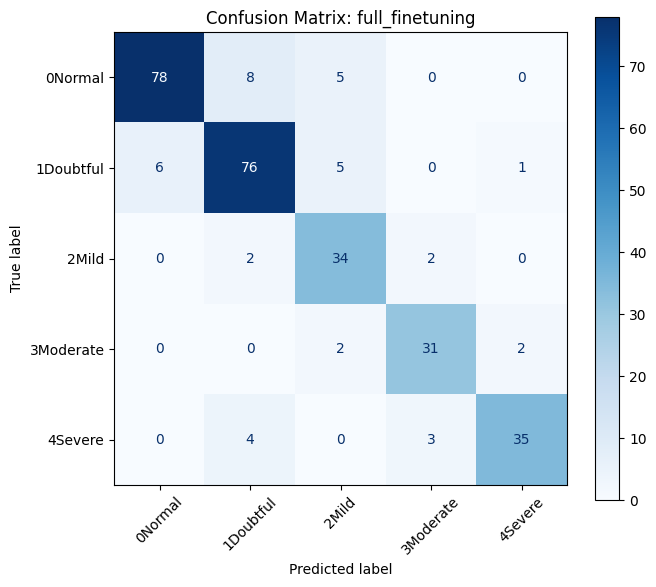

Saved confusion matrix to: /kaggle/working/experiment08_tuned_4crop_finetuning_strategy/figures/confusion_matrix_selected.png


In [39]:
cm = confusion_matrix(selected_true, selected_pred)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", values_format="d", xticks_rotation=45)
plt.title(f"Confusion Matrix: {selected_strategy}")
plt.tight_layout()

cm_path = FIGURES_DIR / "confusion_matrix_selected.png"
fig.savefig(cm_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved confusion matrix to:", cm_path)

## 15. Error Analysis

Because knee OA grading is ordinal, adjacent and distant errors are reported separately.

- adjacent error: prediction differs by 1 grade
- distant error: prediction differs by 2 or more grades

In [40]:
error_df = pd.DataFrame({
    "true": selected_true,
    "pred": selected_pred,
})
error_df["true_class"] = error_df["true"].apply(lambda x: class_names[int(x)])
error_df["pred_class"] = error_df["pred"].apply(lambda x: class_names[int(x)])
error_df["distance"] = (error_df["true"] - error_df["pred"]).abs()
error_df["correct"] = error_df["distance"] == 0
error_df["error_type"] = np.where(
    error_df["distance"] == 0,
    "correct",
    np.where(error_df["distance"] == 1, "adjacent", "distant")
)

display(error_df["error_type"].value_counts())
display(error_df.groupby(["true_class", "pred_class", "error_type"]).size().reset_index(name="count"))

error_df.to_csv(RESULTS_DIR / "selected_error_analysis.csv", index=False)

print("Total samples:", len(error_df))
print("Correct:", int((error_df["distance"] == 0).sum()))
print("Adjacent errors:", int((error_df["distance"] == 1).sum()))
print("Distant errors:", int((error_df["distance"] >= 2).sum()))

error_type
correct     254
adjacent     30
distant      10
Name: count, dtype: int64

,true_class,pred_class,error_type,count
0,0Normal,0Normal,correct,78
1,0Normal,1Doubtful,adjacent,8
2,0Normal,2Mild,distant,5
3,1Doubtful,0Normal,adjacent,6
4,1Doubtful,1Doubtful,correct,76
5,1Doubtful,2Mild,adjacent,5
6,1Doubtful,4Severe,distant,1
7,2Mild,1Doubtful,adjacent,2
8,2Mild,2Mild,correct,34
9,2Mild,3Moderate,adjacent,2


Total samples: 294
Correct: 254
Adjacent errors: 30
Distant errors: 10


wrong samples: 40 / 294
Showing original images directly from file paths. Transforms are not applied.


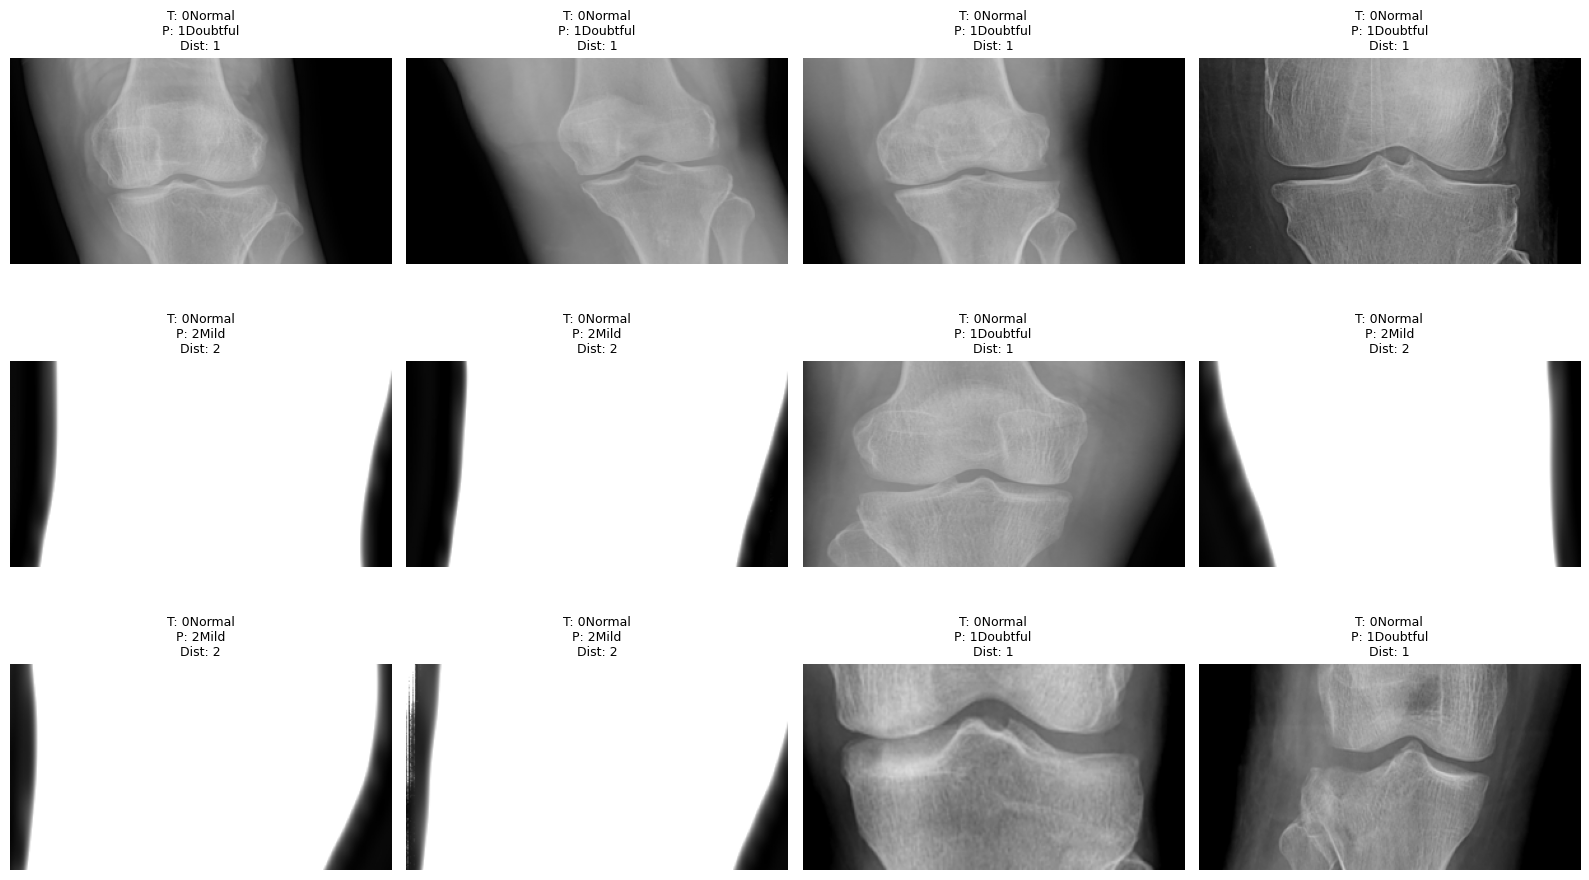

In [41]:
def show_misclassified_raw_images(test_dataset, y_true, y_pred, class_names, max_images=12):
    wrong_indices = [
        i for i, (t, p) in enumerate(zip(y_true, y_pred))
        if int(t) != int(p)
    ]

    print(f"wrong samples: {len(wrong_indices)} / {len(y_true)}")
    print("Showing original images directly from file paths. Transforms are not applied.")

    show_indices = wrong_indices[:max_images]

    if len(show_indices) == 0:
        print("No misclassified samples.")
        return

    cols = 4
    rows = math.ceil(len(show_indices) / cols)

    plt.figure(figsize=(cols * 4, rows * 3.2))

    for plot_i, idx in enumerate(show_indices, start=1):
        img_path, true_label_from_dataset = test_dataset.samples[idx]

        true_label = int(y_true[idx])
        pred_label = int(y_pred[idx])
        dist = abs(true_label - pred_label)

        img = Image.open(img_path).convert("L")

        plt.subplot(rows, cols, plot_i)
        plt.imshow(img, cmap="gray", vmin=0, vmax=255)
        plt.axis("off")
        plt.title(
            f"T: {class_names[true_label]}\n"
            f"P: {class_names[pred_label]}\n"
            f"Dist: {dist}",
            fontsize=9
        )

    plt.tight_layout()
    plt.show()


raw_test_dataset = datasets.ImageFolder(TEST_DIR, transform=None)

show_misclassified_raw_images(
    test_dataset=raw_test_dataset,
    y_true=selected_true,
    y_pred=selected_pred,
    class_names=class_names,
    max_images=12
)

## 16. Grad-CAM

Grad-CAM is used to visualize whether the model focuses on clinically meaningful regions.

This section shows:

1. a correctly classified example
2. an incorrectly classified example

For 4-crop input, Grad-CAM is shown for all four crops.

Correct samples: 254
Wrong samples: 40


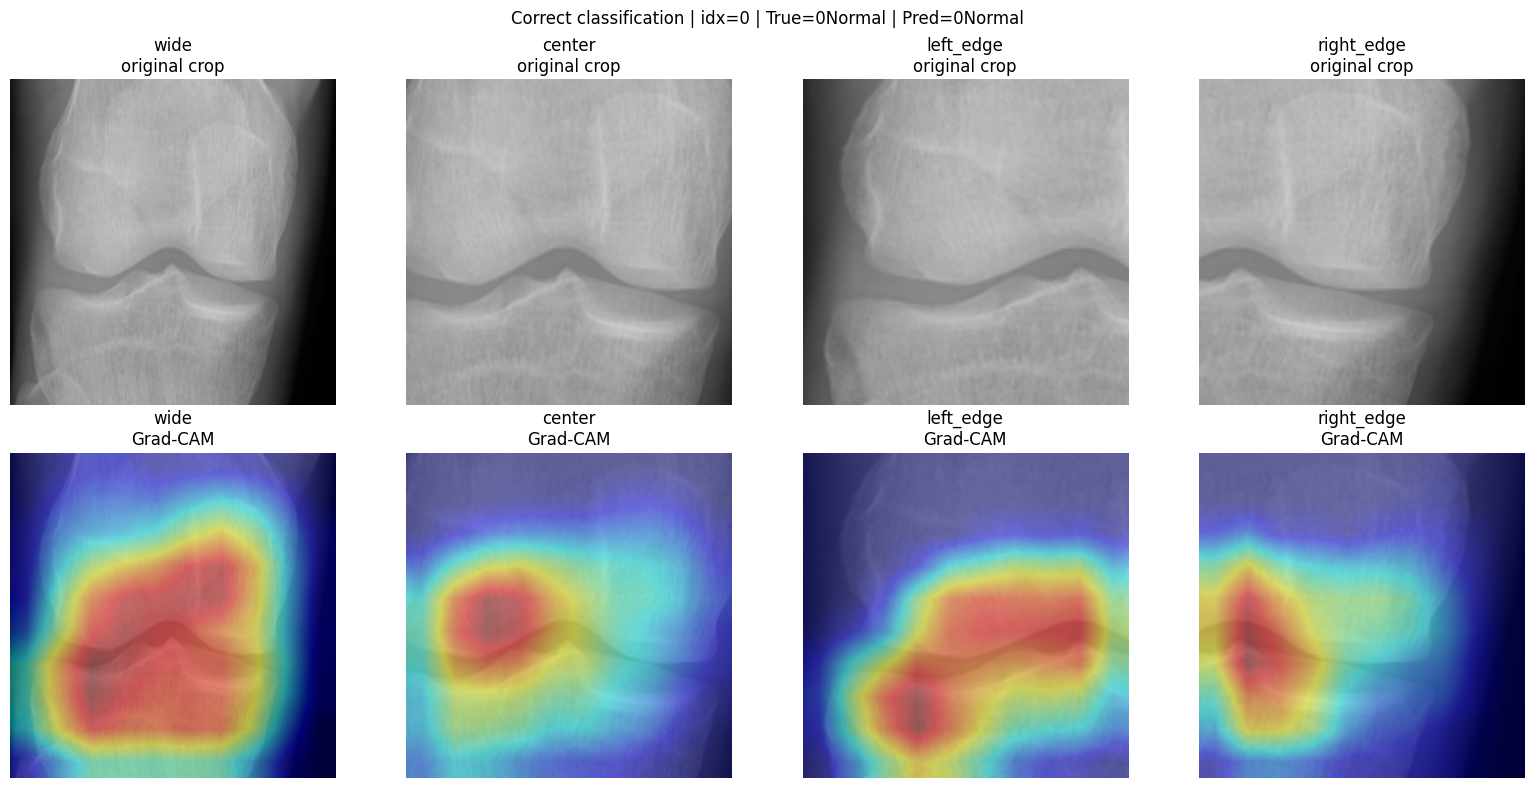

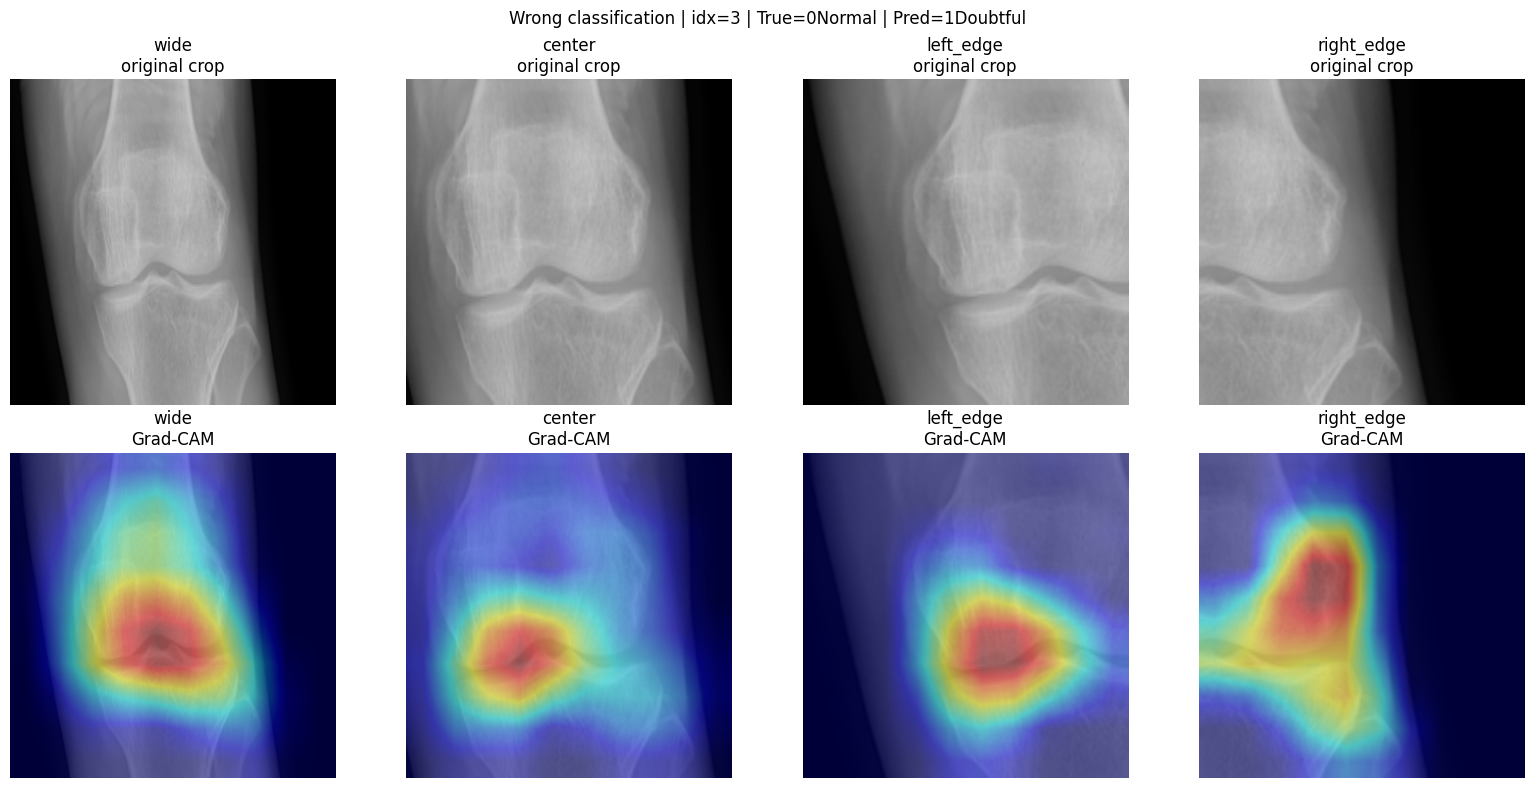

In [45]:
class GradCAM4Crop:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        self.fwd_handle = self.target_layer.register_forward_hook(self._forward_hook)
        self.bwd_handle = self.target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, input, output):
        self.activations = output.detach()

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def remove(self):
        self.fwd_handle.remove()
        self.bwd_handle.remove()

    def generate(self, crops, target_class=None):
        self.model.eval()
        self.model.zero_grad(set_to_none=True)

        crops = crops.unsqueeze(0).to(device)  # [1, 4, 3, H, W]

        logits = self.model(crops)

        if target_class is None:
            target_class = int(torch.argmax(logits, dim=1).item())

        score = logits[0, target_class]
        score.backward()

        # activations/grads shape: [B*N, C, h, w], here [4, C, h, w]
        activations = self.activations
        gradients = self.gradients

        weights = gradients.mean(dim=(2, 3), keepdim=True)
        cams = (weights * activations).sum(dim=1)
        cams = F.relu(cams)

        cam_list = []
        for i in range(cams.size(0)):
            cam = cams[i]
            cam = cam - cam.min()
            if cam.max() > 0:
                cam = cam / cam.max()
            cam_list.append(cam.detach().cpu().numpy())

        return cam_list, logits.detach().cpu()


def overlay_cam_on_image(img_np, cam):
    try:
        import cv2
        cam_resized = cv2.resize(cam, (img_np.shape[1], img_np.shape[0]))
        heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
        overlay = 0.55 * img_np + 0.45 * heatmap
        overlay = np.clip(overlay, 0, 1)
        return overlay
    except Exception:
        # Fallback: just return image; CAM can be shown separately if cv2 is unavailable.
        return img_np


def show_gradcam_for_index(model, dataset, idx, y_true, y_pred, title_prefix="Grad-CAM"):
    crops, label = dataset[idx]

    cam = GradCAM4Crop(model, model.features.norm5)
    cam_list, logits = cam.generate(crops, target_class=int(y_pred[idx]))
    cam.remove()

    pred_label = int(y_pred[idx])
    true_label = int(y_true[idx])

    plt.figure(figsize=(16, 8))

    for i, crop_name in enumerate(CONFIG["CROP_NAMES"]):
        img_np = denormalize_tensor(crops[i])
        overlay = overlay_cam_on_image(img_np, cam_list[i])

        plt.subplot(2, 4, i + 1)
        plt.imshow(img_np)
        plt.title(f"{crop_name}\noriginal crop")
        plt.axis("off")

        plt.subplot(2, 4, i + 5)
        plt.imshow(overlay)
        plt.title(f"{crop_name}\nGrad-CAM")
        plt.axis("off")

    plt.suptitle(
        f"{title_prefix} | idx={idx} | True={class_names[true_label]} | Pred={class_names[pred_label]}",
        fontsize=12
    )
    plt.tight_layout()
    plt.show()


# Load selected best model
best_model = build_model()
best_state = torch.load(best_result["model_path"], map_location=device, weights_only=True)
best_model.load_state_dict(best_state)
best_model.eval()

correct_indices = [
    i for i, (t, p) in enumerate(zip(selected_true, selected_pred))
    if int(t) == int(p)
]
wrong_indices = [
    i for i, (t, p) in enumerate(zip(selected_true, selected_pred))
    if int(t) != int(p)
]

print("Correct samples:", len(correct_indices))
print("Wrong samples:", len(wrong_indices))

if len(correct_indices) > 0:
    show_gradcam_for_index(
        best_model,
        test_dataset,
        correct_indices[0],
        selected_true,
        selected_pred,
        title_prefix="Correct classification"
    )

if len(wrong_indices) > 0:
    show_gradcam_for_index(
        best_model,
        test_dataset,
        wrong_indices[0],
        selected_true,
        selected_pred,
        title_prefix="Wrong classification"
    )

## 17. Final Summary

# Experiment Conclusion

This experiment compared fine-tuning strategies after selecting the tuned 4-crop model and class-weighted HybridChenOrdinalLoss.

The selected final strategy is based on validation QWK. Test metrics, confusion matrix, class-wise F1/recall, adjacent errors, distant errors, and Grad-CAM visualizations are reported to evaluate both classification performance and ordinal grading behaviour.

In [46]:
print("=" * 80)
print("Experiment 08 Final Summary")
print("=" * 80)

print("Selected strategy:", selected_strategy)
print("Model:", CONFIG["MODEL_NAME"])
print("Loss:", CONFIG["LOSS"])
print("Image size:", CONFIG["IMG_SIZE"])
print("Learning rate:", CONFIG["LR"])
print("Ordinal alpha:", CONFIG["ORDINAL_ALPHA"])
print("Dropout:", CONFIG["DROPOUT"])

print("\nSelected test metrics:")
for k in [
    "test_accuracy",
    "test_macro_f1",
    "test_weighted_f1",
    "test_qwk",
    "test_mae",
    "test_total_errors",
    "test_adjacent_errors",
    "test_distant_errors",
]:
    print(f"{k}: {best_result[k]}")

print("\nAll strategy results:")
display(results_df)

Experiment 08 Final Summary
Selected strategy: full_finetuning
Model: 4-crop DenseNet121
Loss: ClassWeightedHybridChenOrdinalLoss
Image size: 320
Learning rate: 5e-05
Ordinal alpha: 0.2
Dropout: 0.3

Selected test metrics:
test_accuracy: 0.8639455782312925
test_macro_f1: 0.8606248803683524
test_weighted_f1: 0.8651066410181131
test_qwk: 0.9151048347386275
test_mae: 0.1870748299319728
test_total_errors: 40
test_adjacent_errors: 30
test_distant_errors: 10

All strategy results:


,strategy,description,best_epoch,best_val_qwk,test_accuracy,test_macro_f1,test_weighted_f1,test_qwk,test_mae,test_total_errors,test_adjacent_errors,test_distant_errors,model_path
0,full_finetuning,Train DenseNet121 backbone and classifier from...,22,0.978448,0.863946,0.860625,0.865107,0.915105,0.187075,40,30,10,/kaggle/working/experiment08_tuned_4crop_finet...
1,freeze_unfreeze,"Freeze DenseNet121 backbone first, then unfree...",18,0.956623,0.853741,0.856258,0.854543,0.909000,0.204082,43,31,12,/kaggle/working/experiment08_tuned_4crop_finet...


## 18. Save Results

The following files are saved:

- `metrics.json`
- `summary.json`
- `finetuning_strategy_results.csv`
- `selected_classwise_recall_f1.csv`
- `selected_error_analysis.csv`
- `confusion_matrix_selected.png`

In [47]:
metrics = {
    "config": CONFIG,
    "crop_config": CROP_CONFIG,
    "selected_strategy": selected_strategy,
    "selected_result": best_result,
    "all_results": results_df.to_dict(orient="records"),
    "classification_report": report_dict,
    "confusion_matrix": cm.tolist(),
}

metrics_path = RESULTS_DIR / "metrics.json"
summary_path = RESULTS_DIR / "summary.json"

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

summary = {
    "experiment_name": CONFIG["EXPERIMENT_NAME"],
    "selected_strategy": selected_strategy,
    "model": CONFIG["MODEL_NAME"],
    "loss": CONFIG["LOSS"],
    "test_accuracy": best_result["test_accuracy"],
    "test_macro_f1": best_result["test_macro_f1"],
    "test_weighted_f1": best_result["test_weighted_f1"],
    "test_qwk": best_result["test_qwk"],
    "test_mae": best_result["test_mae"],
    "test_total_errors": best_result["test_total_errors"],
    "test_adjacent_errors": best_result["test_adjacent_errors"],
    "test_distant_errors": best_result["test_distant_errors"],
}

with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print("Saved metrics to:", metrics_path)
print("Saved summary to:", summary_path)
print("Saved confusion matrix to:", cm_path)
print("Saved results directory:", RESULTS_DIR)
print("Saved figures directory:", FIGURES_DIR)

Saved metrics to: /kaggle/working/experiment08_tuned_4crop_finetuning_strategy/results/metrics.json
Saved summary to: /kaggle/working/experiment08_tuned_4crop_finetuning_strategy/results/summary.json
Saved confusion matrix to: /kaggle/working/experiment08_tuned_4crop_finetuning_strategy/figures/confusion_matrix_selected.png
Saved results directory: /kaggle/working/experiment08_tuned_4crop_finetuning_strategy/results
Saved figures directory: /kaggle/working/experiment08_tuned_4crop_finetuning_strategy/figures
